In [2]:
import pandas as pd
import numpy as np

In [3]:
from sklearn.preprocessing import LabelEncoder

In [4]:
import sys
import sklearn
import numpy
import scipy

print("Python:", sys.version)
print("Scikit-learn:", sklearn.__version__)
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)

Python: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
Scikit-learn: 1.9.0
NumPy: 2.5.1
SciPy: 1.18.0


In [5]:
import sys
print(sys.executable)

import sys
!{sys.executable} -m pip install --upgrade --force-reinstall numpy scipy scikit-learn

c:\Users\SACHIN\AppData\Local\Python\pythoncore-3.14-64\python.exe
  Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl (12.6 MB)
Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

  Attempting uninstall: threadpoolctl

    Found existing installation: threadpoolctl 3.6.0

    Uninstalling threadpoolctl-3.6.0:

   --------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from sklearn.ensemble import IsolationForest

In [7]:
df = pd.read_csv("cleaned_rba_dataset.csv")

In [8]:
df.head()

,Record_ID,Login_Timestamp,User_ID,Round_Trip_Time_ms,IP_Address,Country_name,Region,City,Autonomous_System_Number_ASN,User_Agent_String,Browser_Name_and_Version,OS_Name_and_Version,Device_Type,Login_Successful,Is_Attack_IP,Is_Account_Takeover
0,0,NaN,-4.320000e+18,NaN,10.0.65.171,NO,-,-,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Firefox 20.0.0.1618,iOS 13.4,mobile,False,False,False
1,1,NaN,-4.320000e+18,NaN,194.87.207.6,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 46.0.2490,Android 4.1,mobile,False,False,False
2,2,NaN,-3.280000e+18,NaN,81.167.144.58,NO,Vestland,Urangsvag,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
3,3,NaN,-4.320000e+18,NaN,170.39.78.152,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,False,False,False
4,4,NaN,-4.620000e+18,NaN,10.0.0.47,US,Virginia,Ashburn,398986,Mozilla/5.0 (Linux; U; Android 2.2) Build/NMA...,Chrome Mobile WebView 85.0.4183,Android 2.2,mobile,False,True,False


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Record_ID                     30001 non-null  int64  
 1   Login_Timestamp               11883 non-null  str    
 2   User_ID                       30001 non-null  float64
 3   Round_Trip_Time_ms            1462 non-null   float64
 4   IP_Address                    30001 non-null  str    
 5   Country_name                  30001 non-null  str    
 6   Region                        29968 non-null  str    
 7   City                          29996 non-null  str    
 8   Autonomous_System_Number_ASN  30001 non-null  int64  
 9   User_Agent_String             30001 non-null  str    
 10  Browser_Name_and_Version      30001 non-null  str    
 11  OS_Name_and_Version           30001 non-null  str    
 12  Device_Type                   29999 non-null  str    
 13  Login_Succes

In [10]:
df.isnull().sum()

Record_ID                           0
Login_Timestamp                 18118
User_ID                             0
Round_Trip_Time_ms              28539
IP_Address                          0
Country_name                        0
Region                             33
City                                5
Autonomous_System_Number_ASN        0
User_Agent_String                   0
Browser_Name_and_Version            0
OS_Name_and_Version                 0
Device_Type                         2
Login_Successful                    0
Is_Attack_IP                        0
Is_Account_Takeover                 0
dtype: int64

In [11]:
#Select Required Features
selected_columns = [
    "Country_name",
    "Region",
    "City",
    "Device_Type",
    "Browser_Name_and_Version",
    "OS_Name_and_Version",
    "Round_Trip_Time_ms",
    "Login_Successful",
    "Is_Attack_IP",
    "Is_Account_Takeover"
]

ml_df = df[selected_columns].copy()

ml_df.head()

,Country_name,Region,City,Device_Type,Browser_Name_and_Version,OS_Name_and_Version,Round_Trip_Time_ms,Login_Successful,Is_Attack_IP,Is_Account_Takeover
0,NO,-,-,mobile,Firefox 20.0.0.1618,iOS 13.4,NaN,False,False,False
1,AU,-,-,mobile,Chrome Mobile 46.0.2490,Android 4.1,NaN,False,False,False
2,NO,Vestland,Urangsvag,mobile,Android 2.3.3.2672,iOS 7.1,NaN,True,False,False
3,US,-,-,mobile,Chrome Mobile WebView 85.0.4183,Android 4.1,NaN,False,False,False
4,US,Virginia,Ashburn,mobile,Chrome Mobile WebView 85.0.4183,Android 2.2,NaN,False,True,False


In [12]:
# Encode Categorical Features
# Create Label Encoder
encoder = LabelEncoder()

# List of Categorical Columns
categorical_columns = [
    "Country_name",
    "Region",
    "City",
    "Device_Type",
    "Browser_Name_and_Version",
    "OS_Name_and_Version"
]

In [13]:
# # Convert Text into Numbers
for column in categorical_columns:
    ml_df[column] = encoder.fit_transform(ml_df[column])


# Check Encoded Data
ml_df.head()



,Country_name,Region,City,Device_Type,Browser_Name_and_Version,OS_Name_and_Version,Round_Trip_Time_ms,Login_Successful,Is_Attack_IP,Is_Account_Takeover
0,82,0,0,2,264,118,NaN,False,False,False
1,5,0,0,2,136,12,NaN,False,False,False
2,82,342,1441,2,20,138,NaN,True,False,False
3,106,0,0,2,240,12,NaN,False,False,False
4,106,347,69,2,240,9,NaN,False,True,False


In [14]:
# Verify Data Types
ml_df.dtypes

Country_name                  int64
Region                        int64
City                          int64
Device_Type                   int64
Browser_Name_and_Version      int64
OS_Name_and_Version           int64
Round_Trip_Time_ms          float64
Login_Successful               bool
Is_Attack_IP                   bool
Is_Account_Takeover            bool
dtype: object

In [15]:
print(ml_df.select_dtypes(include="object").columns)

Index([], dtype='str')


In [16]:
# ==========================================
# MACHINE LEARNING - ISOLATION FOREST
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

# Split Dataset (80% Train, 20% Test)
X_train, X_test = train_test_split(
    ml_df,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

# Create Isolation Forest Model
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

print("Isolation Forest Model Created Successfully!")


Training Data Shape : (24000, 10)
Testing Data Shape  : (6001, 10)
Isolation Forest Model Created Successfully!


In [17]:
# Train Model
model.fit(X_train)

print("Model Training Completed Successfully!")

# Predict on Testing Data
predictions = model.predict(X_test)

# Create Test Dataset
test_df = df.loc[X_test.index].copy()

# Add Prediction Column
test_df["Prediction"] = predictions

# Create Threat Status
test_df["Threat_Status"] = test_df["Prediction"].map({
    1: "Normal",
    -1: "Suspicious"
})

print(test_df[["Prediction", "Threat_Status"]].head())


Model Training Completed Successfully!
       Prediction Threat_Status
2308            1        Normal
22405           1        Normal
29877           1        Normal
25059           1        Normal
2664            1        Normal


In [18]:
# ==========================================
# THREAT COUNT
# ==========================================

print(test_df["Threat_Status"].value_counts())

Threat_Status
Normal        5686
Suspicious     315
Name: count, dtype: int64


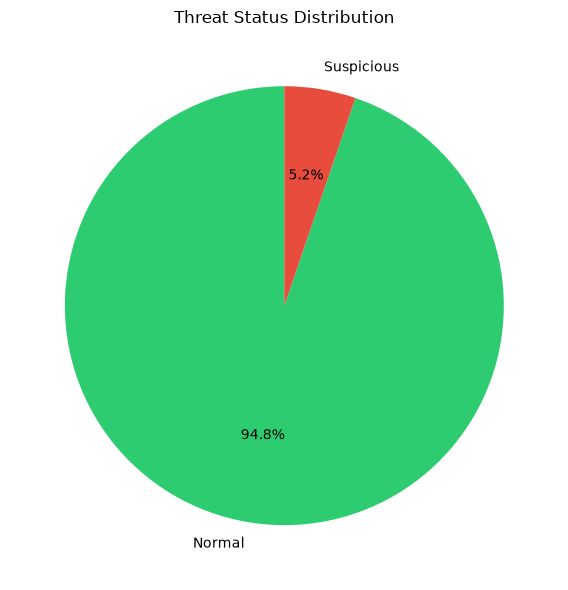

In [19]:
# ==========================================
# PIE CHART
# ==========================================

import matplotlib.pyplot as plt

threat_counts = test_df["Threat_Status"].value_counts()

plt.figure(figsize=(6,6))

threat_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#2ECC71","#E74C3C"],
    startangle=90
)

plt.title("Threat Status Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [20]:
# ==========================================
# SUSPICIOUS RECORDS
# ==========================================

suspicious_records = test_df[test_df["Threat_Status"]=="Suspicious"]

display(suspicious_records.head(10))

,Record_ID,Login_Timestamp,User_ID,Round_Trip_Time_ms,IP_Address,Country_name,Region,City,Autonomous_System_Number_ASN,User_Agent_String,Browser_Name_and_Version,OS_Name_and_Version,Device_Type,Login_Successful,Is_Attack_IP,Is_Account_Takeover,Prediction,Threat_Status
14980,14980,NaN,-8.070000e+18,NaN,80.211.245.68,PL,Mazovia,Warsaw,205727,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Firefox 20.0.0.1656,iOS 11.2.6,mobile,True,True,False,-1,Suspicious
7932,7932,2026-08-05 18:27:54,-4.320000e+18,NaN,10.2.61.63,BR,Sao Paulo,Itapecerica da Serra,500194,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 88.0.4323,Mac OS X 10.14.6,desktop,False,False,False,-1,Suspicious
747,747,NaN,-8.080000e+18,NaN,128.39.188.95,NO,Vestfold og Telemark,Borre,224,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 69.0.3497.17.19,Mac OS X 10.14.6,desktop,True,True,False,-1,Suspicious
2744,2744,2026-08-05 18:15:06,3.780000e+18,576.0,37.191.196.143,NO,Oslo County,Oslo,57963,Mozilla/5.0 (iPad; CPU OS 8_2 like Mac OS X) ...,Android 2.3.6,iOS 8.2,tablet,False,False,False,-1,Suspicious
17410,17410,2026-08-05 09:43:36,6.570000e+18,NaN,37.148.221.43,AU,-,-,60117,Mozilla/5.0 (iPhone; CPU iPhone OS 9_3_4 like...,Chrome Mobile 53.0.2785,iOS 9.3.4,mobile,False,True,False,-1,Suspicious
14976,14976,NaN,-4.320000e+18,NaN,103.141.75.3,ID,West Sumatra,Padang,138892,Opera/9.80 (iPad; CPU OS 7_1 like Mac OS X) P...,Opera Mini 19.0.2254,iOS 7.1,mobile,False,False,False,-1,Suspicious
18056,18056,2026-08-05 17:25:30,-4.320000e+18,NaN,37.148.221.43,AU,-,-,60117,Mozilla/5.0 (iPhone; CPU iPhone OS 9_3_4 like...,Chrome Mobile 53.0.2785,iOS 9.3.4,mobile,False,True,False,-1,Suspicious
2541,2541,2026-08-05 15:57:24,1.170000e+18,NaN,80.211.245.179,PL,Mazovia,Warsaw,205727,Mozilla/5.0 (Linux; U; Android 2.2) AppleWebK...,Chrome Mobile WebView 85.0.4183,Android 2.2,mobile,True,True,False,-1,Suspicious
3507,3507,NaN,-4.320000e+18,NaN,42.81.142.181,CN,Guangdong,Shenzhen,58542,Mozilla/5.0 (Mobile; https://github.com/das-g...,Android 2.2.0.2591,KaiOS 2.0,mobile,False,True,False,-1,Suspicious
3690,3690,NaN,-7.930000e+18,NaN,51.175.104.42,NO,Viken,Lillestrøm,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,False,True,False,-1,Suspicious


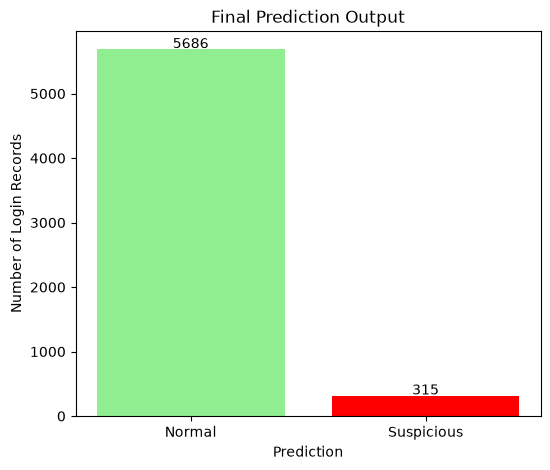

In [ ]:
# ==========================================
# BAR CHART
# ==========================================

normal = (test_df["Prediction"]==1).sum()
anomaly = (test_df["Prediction"]==-1).sum()

plt.figure(figsize=(6,5))

plt.bar(
    ["Normal","Suspicious"],
    [normal,anomaly],
    color=["lightgreen","red"]
)

plt.title("Final Prediction Output")
plt.xlabel("Prediction")
plt.ylabel("Number of Login Records")

plt.text(0,normal+20,str(normal),ha="center")
plt.text(1,anomaly+20,str(anomaly),ha="center")

plt.show()

In [26]:
# ==========================================
# SAVE FINAL DATASET
# ==========================================

test_df.to_csv("ml_prediction.csv",index=False)

print("Machine Learning Completed Successfully!")
print("Final dataset saved as : ml_predictions.csv")

print("Dataset Shape :",test_df.shape)

Machine Learning Completed Successfully!
Final dataset saved as : ml_predictions.csv
Dataset Shape : (6001, 18)


In [27]:
# # Train the Isolation Forest Model
# # Create the model
# model = IsolationForest(
#     n_estimators=100,
#     contamination=0.05,
#     random_state=42
# )

# print("Isolation Forest Model Created Successfully!")

In [28]:
# Train the Model
# model.fit(ml_df)

# print("Model Training Completed Successfully!")

In [29]:
# # Predict Anomalies
# predictions = model.predict(ml_df)

# predictions[:10]

In [30]:
# # Add Predictions to Dataset
# df["Prediction"] = predictions

# df.head()

In [31]:
# # Create Threat Status
# df["Threat_Status"] = df["Prediction"].map({
#     1: "Normal",
#     -1: "Suspicious"
# })

# # Check the results:

# df[["Prediction", "Threat_Status"]].head(10)

In [32]:
# # Count Threats
# df["Threat_Status"].value_counts()

In [33]:
# # Visualize Threat Status
# import matplotlib.pyplot as plt

# threat_counts = df["Threat_Status"].value_counts()

# plt.figure(figsize=(6,6))

# threat_counts.plot(
#     kind="pie",
#     autopct="%1.1f%%",
#     colors=["#2ECC71", "#E74C3C"],
#     startangle=90
# )

# plt.title("Threat Status Distribution")

# plt.ylabel("")

# plt.tight_layout()

# plt.show()

In [34]:
# # View Suspicious Records
# suspicious_records = df[df["Threat_Status"] == "Suspicious"]

# suspicious_records.head(10)

In [35]:
# # Save Final Dataset
# df.to_csv("ml_predictions.csv", index=False)

# print("Machine Learning Completed Successfully!")
# print("Final dataset saved as: ml_predictions.csv")

In [36]:
# print(df.shape)
# print(df[['Prediction', 'Is_Attack_IP']].head())

# saved_df = pd.read_csv("ml_predictions.csv")
# print(saved_df.shape)
# print(saved_df[['Prediction', 'Is_Attack_IP']].head())

In [37]:
# print("Dataset Shape :",saved_df.shape)

In [38]:
# print(df['Is_Attack_IP'].unique())
# print(df['Prediction'].unique())

In [39]:
# y_true = df['Is_Attack_IP'].map({'Yes':1, 'No':0})
# y_pred = df['Prediction'].map({-1:1, 1:0})

In [40]:
# print(df['Is_Attack_IP'].isnull().sum())

In [41]:
# print(df['Is_Attack_IP'].unique())

In [42]:
# # Remove rows with missing labels
# df_eval = df.dropna(subset=['Is_Attack_IP']).copy()

# y_true = df_eval['Is_Attack_IP'].astype(int)
# y_pred = df_eval['Prediction'].map({-1: 1, 1: 0})

# from sklearn.metrics import accuracy_score

# accuracy = accuracy_score(y_true, y_pred)
# print("Accuracy:", accuracy * 100)

In [43]:
# display(df[['Record_ID', 'User_ID', 'Prediction']].head(200))

In [44]:
# print(df['Prediction'].value_counts())
# print(df['Prediction'].unique())

In [45]:
# import matplotlib.pyplot as plt

# normal = (df['Prediction'] == 1).sum()
# anomaly = (df['Prediction'] == -1).sum()

# plt.figure(figsize=(6,5))
# plt.bar(['Normal', 'Suspicious'], [normal, anomaly], color=['lightgreen', 'red'])

# plt.title("Final Prediction Output")
# plt.xlabel("Prediction")
# plt.ylabel("Number of Login Records")

# plt.text(0, normal + 200, str(normal), ha='center')
# plt.text(1, anomaly + 50, str(anomaly), ha='center')

# plt.show()

In [46]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,5))

# # Normal Logins
# plt.scatter(
#     df[df['Prediction'] == 1].index,
#     df[df['Prediction'] == 1]['Prediction'],
#     color='green',
#     s=8,
#     label='Normal'
# )

# # Suspicious Logins
# plt.scatter(
#     df[df['Prediction'] == -1].index,
#     df[df['Prediction'] == -1]['Prediction'],
#     color='red',
#     s=8,
#     label='Suspicious'
# )

# plt.title("Final Prediction Results")
# plt.xlabel("Record Index")
# plt.ylabel("Prediction")
# plt.yticks([-1, 1], ["Suspicious", "Normal"])
# plt.legend()
# plt.grid(True)

# plt.show()